# Financial Performance & Profitability — Exploratory Data Analysis

This notebook is the exploratory pass over the cleaned transaction warehouse: it
works through revenue, profitability, cost, customers and products, and records
what each view actually shows rather than only that it was plotted.

It reads the artefacts the pipeline produces — it does not recompute them — so
every number here is the same number the dashboard and the written report show.
Run `python run_pipeline.py` first if any cell reports a missing file.

**Aggregation happens in SQL wherever a question is naturally a SQL question.**
Pandas is used for shaping and plotting, not as a substitute for the warehouse.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import sys
sys.path.insert(0, str(ROOT))

from src import config
from src.clean_pipeline import load_clean
from src.db_load import get_engine, query

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.max_columns", 40)

plt.rcParams.update({
    "figure.figsize": (11, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})
INK, ACCENT, WARN = "#2b6cb0", "#dd6b20", "#c53030"

engine = get_engine()
df = load_clean()
print(f"{len(df):,} clean transactions, "
      f"{df.transaction_date.min():%d %b %Y} to {df.transaction_date.max():%d %b %Y}")

69,156 clean transactions, 01 Jan 2023 to 31 Dec 2025


---
## 1. What survived cleaning

Before any finding is trusted, it is worth knowing what was thrown away and why.
The cleaning stage quarantines rows rather than deleting them, so the rejects are
auditable.

In [2]:
report = json.loads(config.CLEANING_REPORT.read_text())
summary = report["summary"]
pd.Series(summary).to_frame("value")

,value
raw_rows,71946
clean_rows,69156
rejected_rows,1036
rows_removed_as_duplicates,1754
retention_rate_pct,96.12
rows_with_reconciliation_error,2656
date_range,"[2023-01-01, 2025-12-31]"
total_revenue,"457,600,096.44"
total_cost,"268,126,186.12"
total_profit,"189,473,910.32"


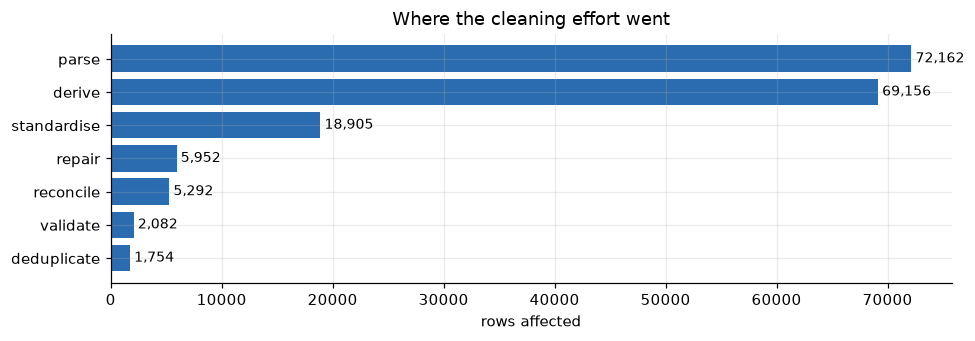

In [3]:
steps = pd.DataFrame(report["steps"])
repairs = (steps[steps.rows_affected > 0]
           .groupby("step", as_index=False).rows_affected.sum()
           .sort_values("rows_affected", ascending=False))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(repairs.step, repairs.rows_affected, color=INK)
ax.invert_yaxis()
ax.set_xlabel("rows affected")
ax.set_title("Where the cleaning effort went")
for y, v in enumerate(repairs.rows_affected):
    ax.text(v, y, f" {v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

The largest single intervention is reconciliation: the source system's `revenue`
column disagrees with `quantity x unit_price x (1 - discount)` on a meaningful
share of rows. The pipeline treats the components as truth and the reported
figure as a claim, so every downstream number is internally consistent by
construction.

In [4]:
mismatch = df.had_reconciliation_error.mean() * 100
overstated = df.loc[df.had_reconciliation_error, "revenue_variance"]
print(f"rows whose reported revenue did not reconcile : {mismatch:5.2f}%")
print(f"net effect of the correction                  : {overstated.sum():>15,.0f}")
print(f"largest single overstatement                  : {overstated.max():>15,.0f}")

rows whose reported revenue did not reconcile :  3.84%
net effect of the correction                  :         196,487
largest single overstatement                  :          69,771


---
## 2. Revenue

### 2.1 How big is the business, and is it growing?

In [5]:
annual = query('''
    SELECT year,
           SUM(revenue)                                   AS revenue,
           SUM(cost)                                      AS cost,
           SUM(profit)                                    AS profit,
           SUM(profit) * 100.0 / SUM(revenue)             AS margin_pct,
           COUNT(*)                                       AS transactions,
           COUNT(DISTINCT customer_id)                    AS customers,
           SUM(revenue) * 1.0 / COUNT(*)                  AS avg_order_value
    FROM fact_transactions
    GROUP BY year ORDER BY year''', engine)

annual["revenue_growth_pct"] = annual.revenue.pct_change() * 100
annual["profit_growth_pct"] = annual.profit.pct_change() * 100
annual["cost_growth_pct"] = annual.cost.pct_change() * 100
annual

,year,revenue,cost,profit,margin_pct,transactions,customers,avg_order_value,revenue_growth_pct,profit_growth_pct,cost_growth_pct
0,2023,"121,897,798.34","69,570,029.63","52,327,768.71",42.93,19432,838,"6,273.04",NaN,NaN,NaN
1,2024,"148,946,460.73","87,444,471.96","61,501,988.77",41.29,23021,966,"6,470.03",22.19,17.53,25.69
2,2025,"186,755,837.37","111,111,684.53","75,644,152.84",40.50,26703,1041,"6,993.81",25.38,22.99,27.07


Two things stand out immediately and they point in opposite directions: revenue
is growing strongly, and margin is falling every year. The rest of the notebook
is largely an attempt to explain the second.

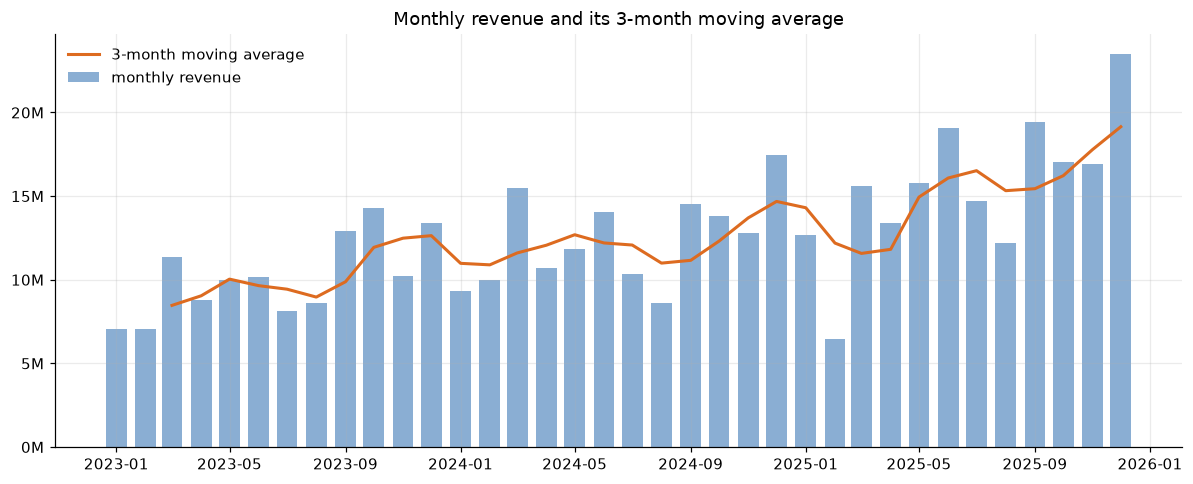

In [6]:
monthly = query('''
    SELECT year_month,
           MIN(transaction_date)              AS month_start,
           SUM(revenue)                       AS revenue,
           SUM(cost)                          AS cost,
           SUM(profit)                        AS profit,
           SUM(gross_revenue)                 AS gross_revenue,
           SUM(discount_amount)               AS discount_amount,
           COUNT(*)                           AS transactions,
           COUNT(DISTINCT customer_id)        AS customers
    FROM fact_transactions
    GROUP BY year_month ORDER BY year_month''', engine)

monthly["month_start"] = pd.to_datetime(monthly.month_start)
monthly["margin_pct"] = monthly.profit / monthly.revenue * 100
monthly["discount_rate_pct"] = monthly.discount_amount / monthly.gross_revenue * 100
monthly["revenue_ma3"] = monthly.revenue.rolling(3).mean()
monthly["revenue_mom_pct"] = monthly.revenue.pct_change() * 100
monthly["revenue_yoy_pct"] = monthly.revenue.pct_change(12) * 100

fig, ax = plt.subplots()
ax.bar(monthly.month_start, monthly.revenue, width=22, color=INK, alpha=0.55,
       label="monthly revenue")
ax.plot(monthly.month_start, monthly.revenue_ma3, color=ACCENT, lw=2,
        label="3-month moving average")
ax.set_title("Monthly revenue and its 3-month moving average")
ax.yaxis.set_major_formatter(lambda v, _: f"{v/1e6:.0f}M")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The moving average is the useful line here. Monthly revenue swings hard — the
December peak is roughly double a quiet month — so month-on-month comparisons on
the raw series mostly measure the calendar. Where the bars sit below the smoothed
line for several consecutive months, something other than seasonality is at work.

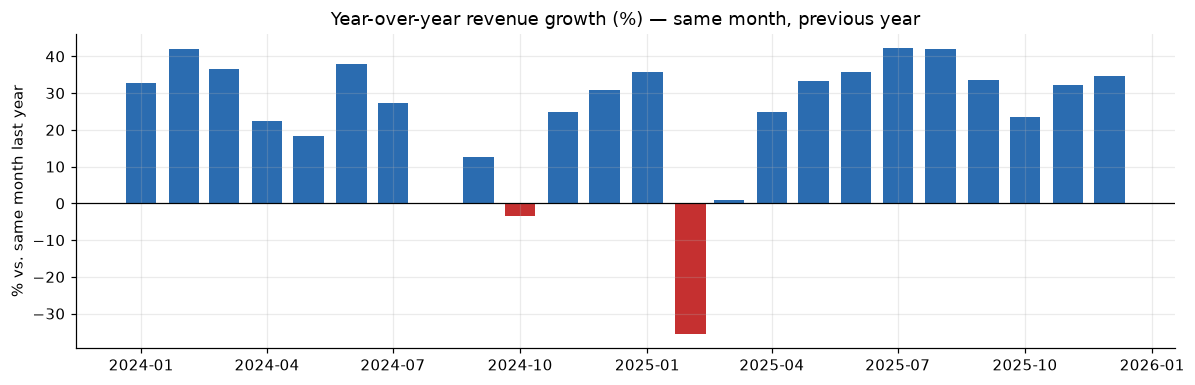

mean    24.37
min    -35.48
max     42.15


In [7]:
fig, ax = plt.subplots(figsize=(11, 3.6))
colours = [WARN if v < 0 else INK for v in monthly.revenue_yoy_pct]
ax.bar(monthly.month_start, monthly.revenue_yoy_pct, width=22, color=colours)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Year-over-year revenue growth (%) — same month, previous year")
ax.set_ylabel("% vs. same month last year")
plt.tight_layout(); plt.show()

print(monthly.revenue_yoy_pct.describe()[["mean", "min", "max"]].to_string())

Year-over-year is the honest growth measure for a seasonal business: it compares
December with December. Growth is positive nearly throughout, which confirms the
top line is genuinely expanding rather than drifting with the calendar.

### 2.2 Where does revenue come from?

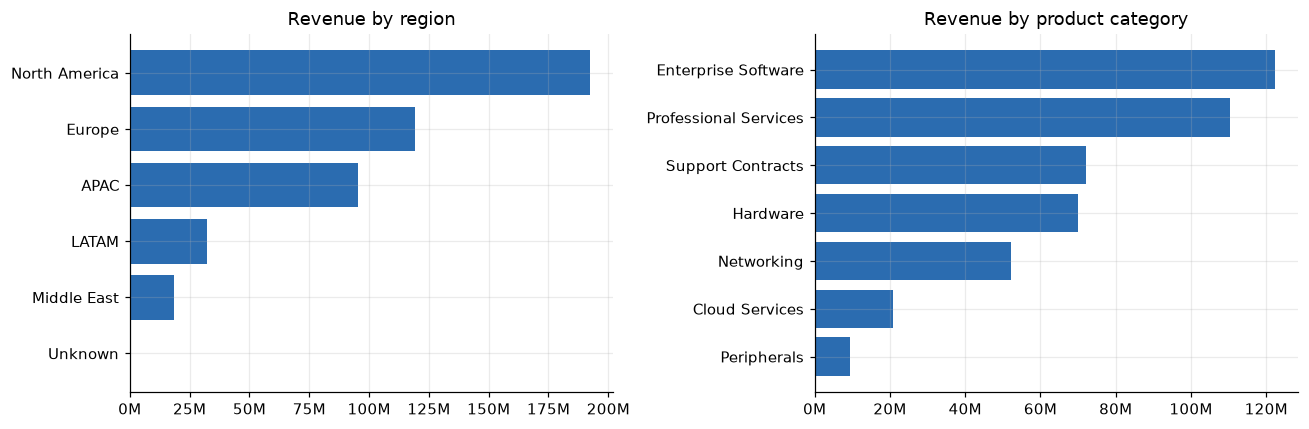

,region,revenue,profit,margin_pct,customers,share_pct
0,North America,"192,410,448.00","79,434,239.02",41.28,471,42.05
1,Europe,"119,316,666.04","48,868,820.19",40.96,317,26.07
2,APAC,"95,248,109.63","39,220,661.18",41.18,221,20.81
3,LATAM,"32,137,477.07","13,615,172.51",42.37,109,7.02
4,Middle East,"18,459,710.25","8,320,106.61",45.07,74,4.03
5,Unknown,"27,685.45","14,910.81",53.86,1,0.01


In [8]:
by_region = query('''
    SELECT region,
           SUM(revenue)                        AS revenue,
           SUM(profit)                         AS profit,
           SUM(profit) * 100.0 / SUM(revenue)  AS margin_pct,
           COUNT(DISTINCT customer_id)         AS customers
    FROM fact_transactions
    GROUP BY region ORDER BY revenue DESC''', engine)
by_region["share_pct"] = by_region.revenue / by_region.revenue.sum() * 100

by_category = query('''
    SELECT product_category,
           SUM(revenue)                        AS revenue,
           SUM(profit)                         AS profit,
           SUM(profit) * 100.0 / SUM(revenue)  AS margin_pct,
           SUM(discount_amount) * 100.0 / SUM(gross_revenue) AS discount_rate_pct
    FROM fact_transactions
    GROUP BY product_category ORDER BY revenue DESC''', engine)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(by_region.region, by_region.revenue, color=INK)
axes[0].invert_yaxis(); axes[0].set_title("Revenue by region")
axes[0].xaxis.set_major_formatter(lambda v, _: f"{v/1e6:.0f}M")

axes[1].barh(by_category.product_category, by_category.revenue, color=INK)
axes[1].invert_yaxis(); axes[1].set_title("Revenue by product category")
axes[1].xaxis.set_major_formatter(lambda v, _: f"{v/1e6:.0f}M")
plt.tight_layout(); plt.show()

by_region

**Scale and profitability are not the same ranking.** Plotting margin against
revenue for the same regions makes the gap explicit — the biggest region is not
the best one.

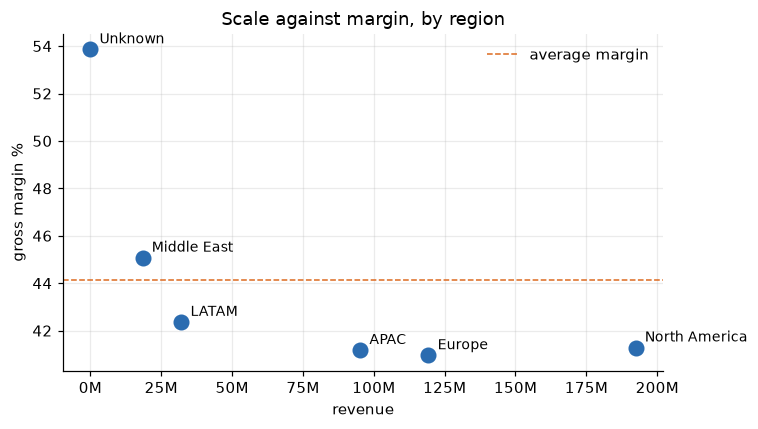

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(by_region.revenue, by_region.margin_pct, s=90, color=INK, zorder=3)
for _, r in by_region.iterrows():
    ax.annotate(r.region, (r.revenue, r.margin_pct),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axhline(by_region.margin_pct.mean(), color=ACCENT, ls="--", lw=1,
           label="average margin")
ax.set_xlabel("revenue"); ax.set_ylabel("gross margin %")
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1e6:.0f}M")
ax.set_title("Scale against margin, by region")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---
## 3. Profitability — the margin decline

Revenue is growing and margin is falling. This section works out which of the
plausible explanations the data actually supports.

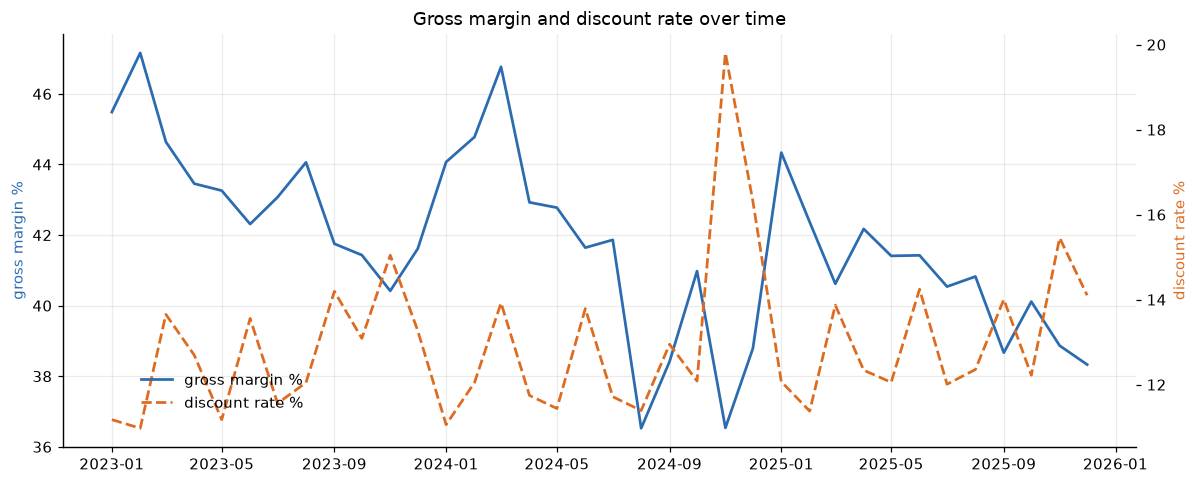

correlation between monthly margin and monthly discount rate: -0.528


In [10]:
fig, ax1 = plt.subplots()
ax1.plot(monthly.month_start, monthly.margin_pct, color=INK, lw=1.8,
         label="gross margin %")
ax1.set_ylabel("gross margin %", color=INK)
ax2 = ax1.twinx()
ax2.plot(monthly.month_start, monthly.discount_rate_pct, color=ACCENT, lw=1.8,
         ls="--", label="discount rate %")
ax2.set_ylabel("discount rate %", color=ACCENT)
ax2.grid(False)
ax1.set_title("Gross margin and discount rate over time")
fig.legend(loc="lower left", bbox_to_anchor=(0.11, 0.13), frameon=False)
plt.tight_layout(); plt.show()

print("correlation between monthly margin and monthly discount rate: "
      f"{monthly.margin_pct.corr(monthly.discount_rate_pct):+.3f}")

The two lines move as near-mirror images. That is suggestive, not conclusive —
at the monthly level there are only 36 observations and plenty of confounders —
so the question gets a formal test below rather than an eyeball verdict.

### 3.1 Is discounting the cause?

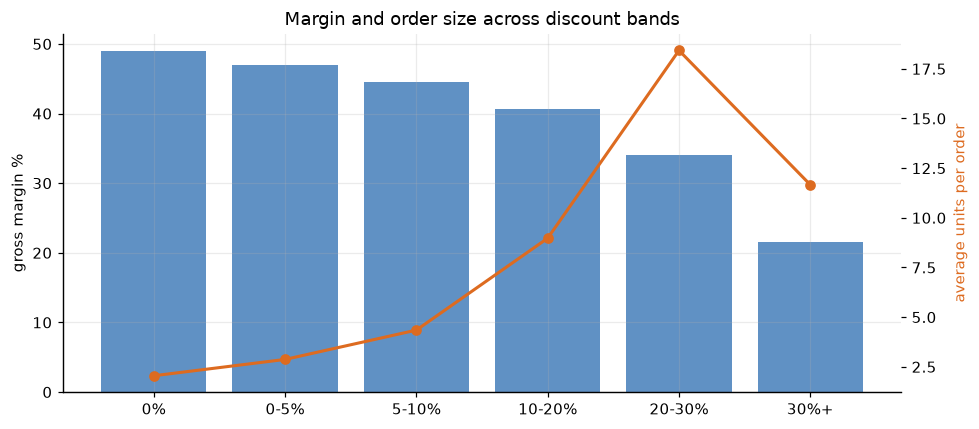

,discount_band,transactions,margin_pct,avg_quantity,avg_order_value
0,0%,1062,48.96,2.05,"2,351.07"
1,0-5%,12137,46.95,2.87,"3,086.76"
2,5-10%,25231,44.58,4.35,"4,671.01"
3,10-20%,27419,40.70,8.97,"9,023.72"
4,20-30%,2951,34.01,18.43,"16,654.23"
5,30%+,356,21.50,11.66,"9,036.78"


In [11]:
bands = query('''
    SELECT CASE
             WHEN discount = 0            THEN '0%'
             WHEN discount <= 0.05        THEN '0-5%'
             WHEN discount <= 0.10        THEN '5-10%'
             WHEN discount <= 0.20        THEN '10-20%'
             WHEN discount <= 0.30        THEN '20-30%'
             ELSE '30%+'
           END                                        AS discount_band,
           COUNT(*)                                   AS transactions,
           SUM(revenue)                               AS revenue,
           SUM(profit) * 100.0 / SUM(revenue)         AS margin_pct,
           AVG(revenue)                               AS avg_order_value,
           AVG(quantity)                              AS avg_quantity
    FROM fact_transactions
    GROUP BY discount_band''', engine)

order = ['0%', '0-5%', '5-10%', '10-20%', '20-30%', '30%+']
bands = bands.set_index("discount_band").reindex(order).dropna(how="all").reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(bands.discount_band, bands.margin_pct, color=INK, alpha=0.75)
ax1.set_ylabel("gross margin %")
ax2 = ax1.twinx()
ax2.plot(bands.discount_band, bands.avg_quantity, color=ACCENT, marker="o", lw=2)
ax2.set_ylabel("average units per order", color=ACCENT); ax2.grid(False)
ax1.set_title("Margin and order size across discount bands")
plt.tight_layout(); plt.show()

bands[["discount_band", "transactions", "margin_pct", "avg_quantity",
       "avg_order_value"]]

Margin falls monotonically across the bands, and the volume that the discount is
supposed to buy does not rise nearly fast enough to pay for it. That is the
shape of margin being given away rather than invested.

The formal test — Welch's t-test on transaction-level margin, heavy versus light
discounting — is in `src/stats_analysis.py` and its saved result is loaded here
rather than recomputed, so the notebook and the report cannot disagree.

In [12]:
stats_out = json.loads((config.REPORTS_DIR / "statistical_analysis.json").read_text())
tests = pd.DataFrame([{
    "question": t["question"],
    "test": t["test"],
    "p_value": t["p_value"],
    "effect": (t.get("effect_size") or {}).get("magnitude", ""),
    "decision": t["decision"],
} for t in stats_out["hypothesis_tests"]])
tests

,question,test,p_value,effect,decision
0,Does giving higher discounts significantly red...,Welch's two-sample t-test (unequal variances),0.00,small,Reject the null hypothesis
1,Is average order value significantly different...,Welch's two-sample t-test (unequal variances),0.00,negligible,Reject the null hypothesis
2,Are there statistically significant difference...,One-way ANOVA with Tukey HSD post-hoc,0.00,negligible,Reject the null hypothesis
3,Has transaction-level profit margin declined b...,Welch's two-sample t-test (unequal variances),0.00,negligible,Reject the null hypothesis
4,Did hardware margin in Aug-Oct 2024 differ fro...,Welch's two-sample t-test on matched calendar ...,0.00,large,Reject the null hypothesis
5,Do different customer segments pay in differen...,Chi-square test of independence,0.00,small,Reject the null hypothesis
6,Do weekend transactions differ in value from w...,Welch's two-sample t-test (unequal variances),0.33,negligible,Fail to reject the null hypothesis


### 3.2 Or is it cost?

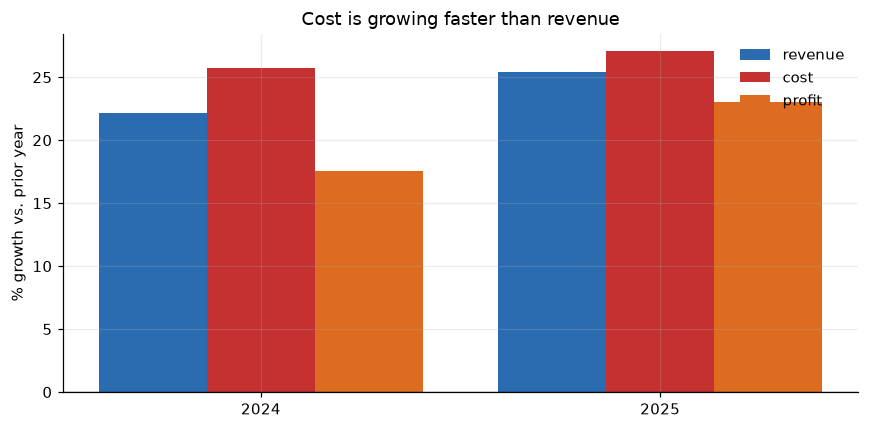

In [13]:
growth = annual[["year", "revenue_growth_pct", "cost_growth_pct",
                 "profit_growth_pct"]].dropna()

x = np.arange(len(growth)); w = 0.27
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w, growth.revenue_growth_pct, w, label="revenue", color=INK)
ax.bar(x, growth.cost_growth_pct, w, label="cost", color=WARN)
ax.bar(x + w, growth.profit_growth_pct, w, label="profit", color=ACCENT)
ax.set_xticks(x); ax.set_xticklabels(growth.year.astype(int))
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("% growth vs. prior year")
ax.set_title("Cost is growing faster than revenue")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**This is the mechanical answer to the margin question.** In every year where
cost growth exceeds revenue growth, margin has to fall — it is arithmetic, not
inference. Discounting and cost inflation are both real and they compound.

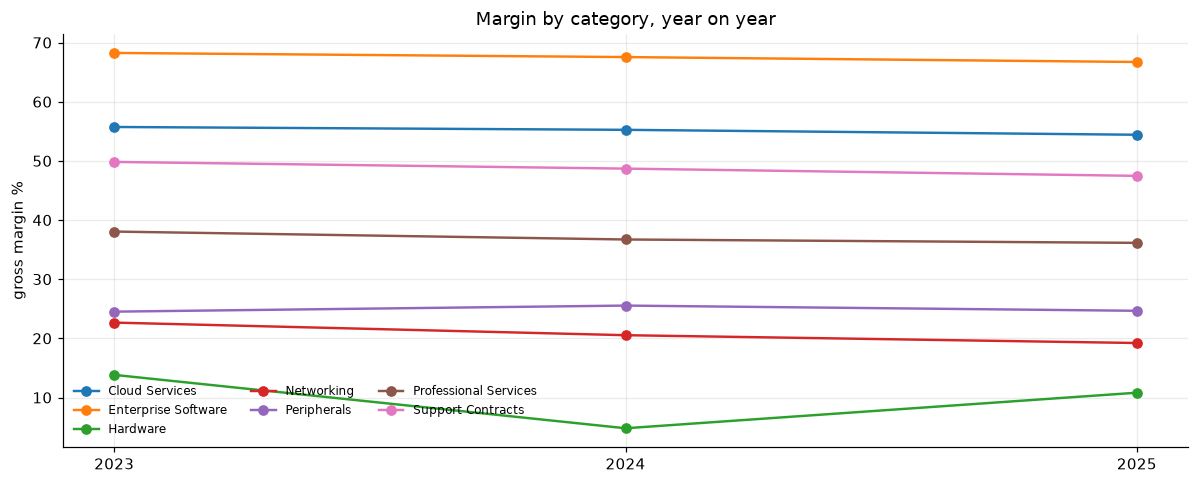

,"margin change, pp"
product_category,
Networking,-3.45
Hardware,-3.01
Support Contracts,-2.36
Professional Services,-1.91
Enterprise Software,-1.53
Cloud Services,-1.31
Peripherals,0.14


In [14]:
category_margin = query('''
    SELECT product_category, year,
           SUM(profit) * 100.0 / SUM(revenue) AS margin_pct
    FROM fact_transactions
    GROUP BY product_category, year''', engine)

pivot = category_margin.pivot(index="year", columns="product_category",
                              values="margin_pct")
fig, ax = plt.subplots()
for column in pivot.columns:
    ax.plot(pivot.index, pivot[column], marker="o", lw=1.6, label=column)
ax.set_xticks(pivot.index.astype(int))
ax.set_ylabel("gross margin %")
ax.set_title("Margin by category, year on year")
ax.legend(frameon=False, ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

(pivot.iloc[-1] - pivot.iloc[0]).sort_values().to_frame("margin change, pp")

The decline is not uniform. One category falls much further than the others,
which is where an operational investigation would start — a company-wide margin
programme would be aimed at the wrong place.

---
## 4. Customers

### 4.1 Concentration

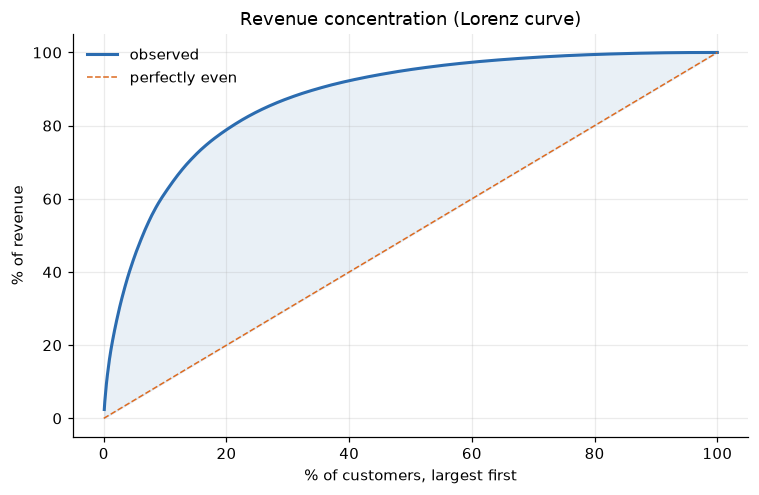

top 10 customers  :  15.1% of revenue
top 20% of accounts:  78.8% of revenue
customers          : 1,187


In [15]:
customer_revenue = query('''
    SELECT customer_id, SUM(revenue) AS revenue, COUNT(*) AS transactions
    FROM fact_transactions
    WHERE is_customer_attributed = 1
    GROUP BY customer_id ORDER BY revenue DESC''', engine)

total = customer_revenue.revenue.sum()
customer_revenue["cumulative_pct"] = customer_revenue.revenue.cumsum() / total * 100
customer_revenue["customer_pct"] = (np.arange(1, len(customer_revenue) + 1)
                                    / len(customer_revenue) * 100)

top10_share = customer_revenue.head(10).revenue.sum() / total * 100
top20pct = customer_revenue[customer_revenue.customer_pct <= 20].cumulative_pct.max()

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(customer_revenue.customer_pct, customer_revenue.cumulative_pct,
        color=INK, lw=2, label="observed")
ax.plot([0, 100], [0, 100], color=ACCENT, ls="--", lw=1, label="perfectly even")
ax.fill_between(customer_revenue.customer_pct, customer_revenue.cumulative_pct,
                customer_revenue.customer_pct, color=INK, alpha=0.10)
ax.set_xlabel("% of customers, largest first")
ax.set_ylabel("% of revenue")
ax.set_title("Revenue concentration (Lorenz curve)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"top 10 customers  : {top10_share:5.1f}% of revenue")
print(f"top 20% of accounts: {top20pct:5.1f}% of revenue")
print(f"customers          : {len(customer_revenue):,}")

The curve bows well above the diagonal: revenue is concentrated. That is a
commercial risk worth stating plainly — losing a handful of accounts would be
material — but it is not unusual for a B2B business, and the concentration is
nowhere near the pathological case where a single account dominates.

In [16]:
segments = query('''
    SELECT customer_segment,
           COUNT(DISTINCT customer_id)                  AS customers,
           COUNT(*)                                     AS transactions,
           SUM(revenue)                                 AS revenue,
           SUM(profit) * 100.0 / SUM(revenue)           AS margin_pct,
           SUM(revenue) * 1.0 / COUNT(*)                AS avg_order_value,
           SUM(revenue) * 1.0 / COUNT(DISTINCT customer_id) AS revenue_per_customer
    FROM fact_transactions
    WHERE is_customer_attributed = 1
    GROUP BY customer_segment ORDER BY revenue DESC''', engine)
segments

,customer_segment,customers,transactions,revenue,margin_pct,avg_order_value,revenue_per_customer
0,Enterprise,110,15146,"198,280,305.18",38.62,"13,091.27","1,802,548.23"
1,Mid-Market,314,29099,"180,425,345.26",42.76,"6,200.40","574,603.01"
2,SMB,472,18729,"64,424,137.07",45.15,"3,439.81","136,491.82"
3,Retail,291,5631,"10,672,435.32",46.70,"1,895.30","36,675.04"


### 4.2 Repeat behaviour

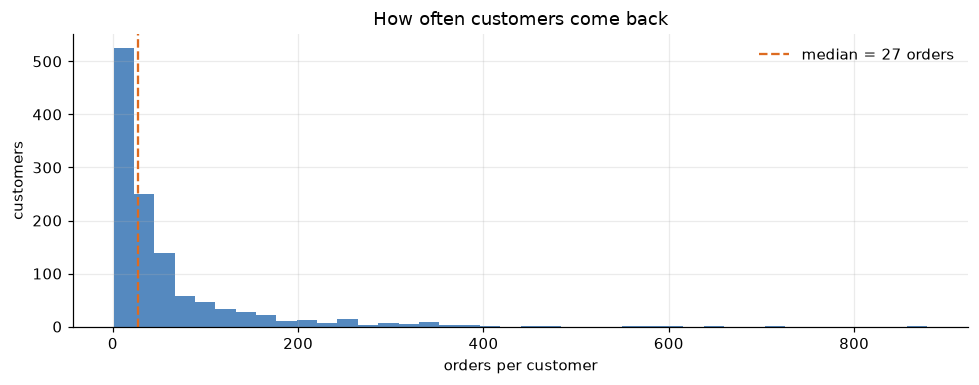

customers with more than one order: 98.3%


In [17]:
repeat = customer_revenue.transactions
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(repeat, bins=40, color=INK, alpha=0.8)
ax.axvline(repeat.median(), color=ACCENT, ls="--",
           label=f"median = {repeat.median():.0f} orders")
ax.set_xlabel("orders per customer"); ax.set_ylabel("customers")
ax.set_title("How often customers come back")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"customers with more than one order: "
      f"{(repeat > 1).mean() * 100:.1f}%")

---
## 5. Products

The question management actually asks is not "what sells?" but "what should we
look at?" — products that are large enough to matter and unprofitable enough to
be worth the meeting.

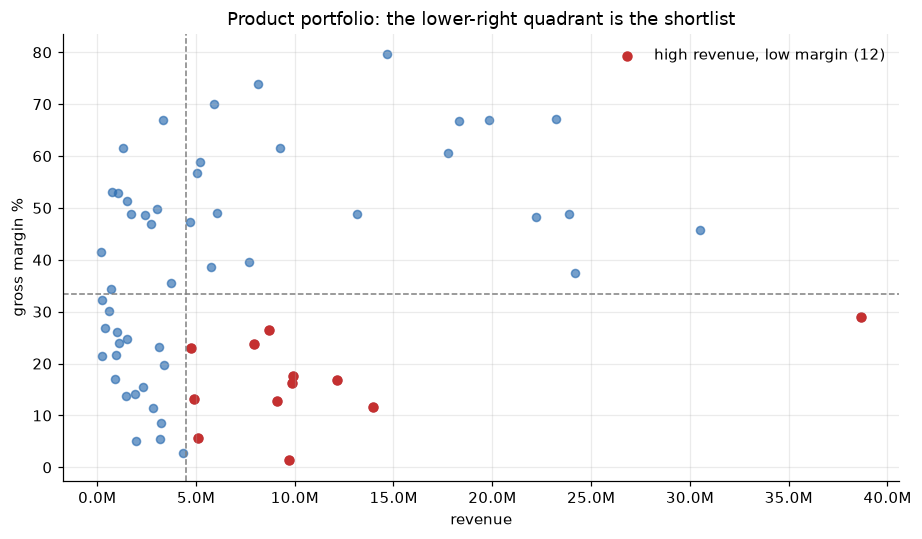

,product_name,product_category,revenue,margin_pct,discount_rate_pct
14,Hardware F807,Hardware,"9,708,949.19",1.35,12.94
15,Hardware G202,Hardware,"5,090,699.20",5.68,13.34
12,Hardware D315,Hardware,"13,955,060.64",11.63,12.85
17,Hardware I787,Hardware,"9,097,252.79",12.85,13.37
11,Hardware C702,Hardware,"4,902,790.53",13.21,13.13
16,Hardware H171,Hardware,"9,874,893.25",16.35,12.77
27,Networking G787,Networking,"12,152,305.04",16.92,12.84
22,Networking B195,Networking,"9,917,428.29",17.69,13.21
21,Networking A467,Networking,"4,763,537.96",22.94,12.97
23,Networking C909,Networking,"7,943,362.00",23.80,14.34


In [18]:
products = query('''
    SELECT p.product_id, p.product_name, p.product_category,
           SUM(f.quantity)                                AS units,
           SUM(f.revenue)                                 AS revenue,
           SUM(f.profit)                                  AS profit,
           SUM(f.profit) * 100.0 / SUM(f.revenue)         AS margin_pct,
           SUM(f.discount_amount) * 100.0
               / NULLIF(SUM(f.gross_revenue), 0)          AS discount_rate_pct
    FROM fact_transactions f
    JOIN dim_product p ON f.product_id = p.product_id
    GROUP BY p.product_id, p.product_name, p.product_category''', engine)

median_revenue = products.revenue.median()
median_margin = products.margin_pct.median()

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(products.revenue, products.margin_pct, s=28, alpha=0.65, color=INK)
ax.axvline(median_revenue, color="grey", lw=1, ls="--")
ax.axhline(median_margin, color="grey", lw=1, ls="--")

investigate = products[(products.revenue > median_revenue)
                       & (products.margin_pct < median_margin)]
ax.scatter(investigate.revenue, investigate.margin_pct, s=34, color=WARN,
           label=f"high revenue, low margin ({len(investigate)})")
ax.set_xlabel("revenue"); ax.set_ylabel("gross margin %")
ax.xaxis.set_major_formatter(lambda v, _: f"{v/1e6:.1f}M")
ax.set_title("Product portfolio: the lower-right quadrant is the shortlist")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

investigate.nsmallest(10, "margin_pct")[
    ["product_name", "product_category", "revenue", "margin_pct",
     "discount_rate_pct"]]

These are the products carrying real volume at poor margin. Each one is either a
pricing decision, a discounting decision, or a cost problem — and the discount
rate column usually says which.

---
## 6. Seasonality and time-series structure

Loaded from the saved time-series analysis so the notebook agrees with the
report and the dashboard.

In [19]:
ts = json.loads((config.REPORTS_DIR / "timeseries_analysis.json").read_text())
trend, seasonal = ts["trend"], ts["seasonality"]

print(f"trend method       : {trend['method']}")
print(f"monthly growth rate: {trend['monthly_growth_rate_pct']:+.2f}%")
print(f"implied annual     : {trend['implied_annual_growth_pct']:+.1f}%")
print(f"R-squared          : {trend['r_squared']:.3f}")
print(f"peak month         : {seasonal['peak_month']} "
      f"(index {seasonal['peak_index']:.2f})")
print(f"trough month       : {seasonal['trough_month']} "
      f"(index {seasonal['trough_index']:.2f})")

trend method       : OLS on log(revenue) against period index
monthly growth rate: +2.02%
implied annual     : +27.4%
R-squared          : 0.477
peak month         : December (index 1.25)
trough month       : February (index 0.65)


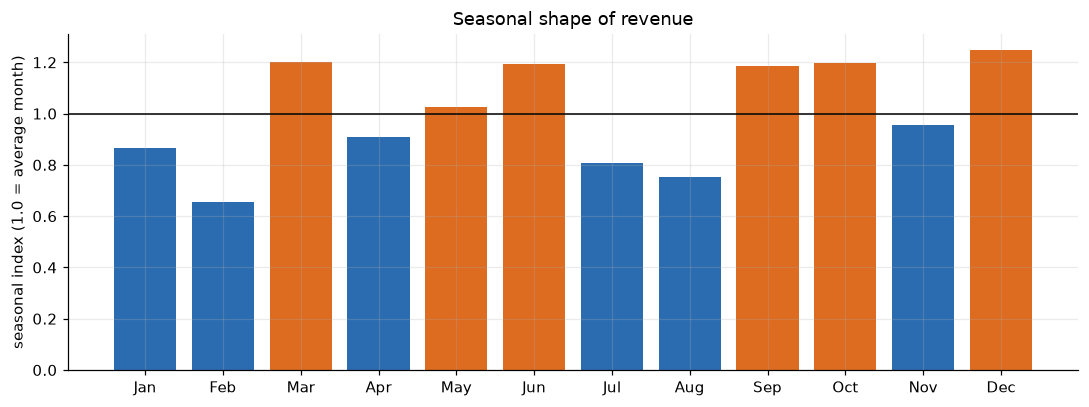

In [20]:
index = pd.DataFrame(seasonal["seasonal_index"])
fig, ax = plt.subplots(figsize=(10, 3.8))
colours = [ACCENT if v >= 1 else INK for v in index.seasonal_index]
ax.bar(index.month_name.str[:3], index.seasonal_index, color=colours)
ax.axhline(1.0, color="black", lw=1)
ax.set_ylabel("seasonal index (1.0 = average month)")
ax.set_title("Seasonal shape of revenue")
plt.tight_layout(); plt.show()

A December index well above 1 and a February trough well below it: the swing is
large enough that any month-on-month commentary that ignores it will be wrong
about half the time. This is why the KPI comparisons elsewhere in the project use
trailing-twelve-month windows.

---
## 7. Anomalies

Four classical detectors, no machine learning: global z-score, rolling z-score,
seasonal-residual z-score on the STL remainder, and Tukey IQR fences. Each flag
carries an expected range and a plain-language reading.

In [21]:
anomalies = json.loads((config.REPORTS_DIR / "anomaly_report.json").read_text())
print(f"total flags     : {anomalies['total_anomalies']}")
print(f"material flags  : {anomalies['material_flags']}")
print(f"by severity     : {anomalies['by_severity']}")

scoring = anomalies["ground_truth_scoring"]
if scoring.get("available"):
    print(f"\nplanted events  : {scoring['events_injected']}")
    print(f"events recovered: {scoring['events_recovered']} "
          f"({scoring['recall_pct']:.0f}% recall)")

total flags     : 103
material flags  : 97
by severity     : {'Critical': 38, 'High': 28, 'Medium': 19, 'Low': 18}

planted events  : 7
events recovered: 7 (100% recall)


The generator records what it injected, so the monitor can be scored against
ground truth rather than against its own output — that is the difference between
"the detectors produced flags" and "the detectors work".

In [22]:
top = pd.DataFrame(anomalies["top_anomalies"])
critical = top[top.severity == "Critical"].head(8)
critical[["period", "scope", "metric", "actual", "expected",
          "deviation_pct", "severity"]]

,period,scope,metric,actual,expected,deviation_pct,severity
0,2023-09-01,Category: Peripherals,Category profit margin,-10.34,27.49,-137.64,Critical
1,2025-02-01,Company-wide,Transaction volume,994.00,"1,771.61",-43.89,Critical
2,2024-08-01,Category: Hardware,Category profit margin,-20.03,13.34,-250.15,Critical
3,2025-01-01,Expense: Rent & Facilities,Operating expense,"317,733.94","224,948.40",41.25,Critical
4,2024-11-01,Region: Europe,Regional discount rate,33.64,11.82,184.76,Critical
5,2025-06-01,Marketing efficiency,Marketing spend as % of revenue,22.06,9.83,124.32,Critical
6,2025-02-01,Company-wide,Monthly revenue,"6,435,892.51","12,455,037.23",-48.33,Critical
7,2025-02-01,Company-wide,Monthly profit,"2,726,914.14","5,473,696.00",-50.18,Critical


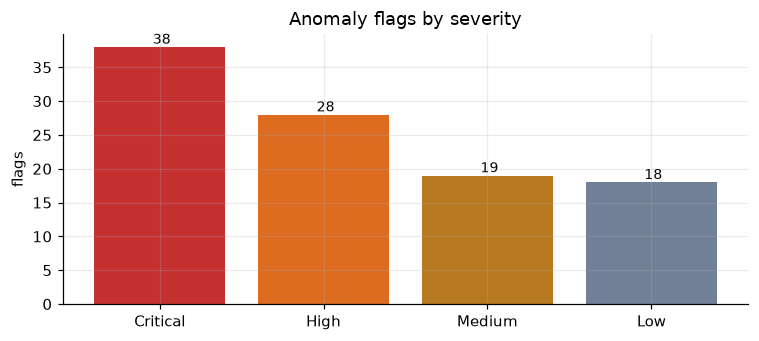

In [23]:
severity_counts = pd.Series(anomalies["by_severity"])
order = [s for s in ["Critical", "High", "Medium", "Low"]
         if s in severity_counts.index]
palette = {"Critical": WARN, "High": ACCENT, "Medium": "#b7791f", "Low": "#718096"}

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(order, severity_counts[order], color=[palette[s] for s in order])
ax.set_ylabel("flags"); ax.set_title("Anomaly flags by severity")
for i, s in enumerate(order):
    ax.text(i, severity_counts[s], f" {severity_counts[s]}", ha="center",
            va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

Severity is graded on statistical extremity and then tempered by materiality: a
very stable series (fixed rent, say) produces enormous z-scores for moves no
finance team would act on, so an immaterial flag is capped at Low. It is still
reported — it is real — but it cannot crowd out the findings that matter.

---
## 8. What the exploration found

| Question | Answer |
|---|---|
| Is revenue growing? | Yes, and the year-over-year series confirms it is genuine growth rather than seasonality. |
| Is the business getting more profitable? | No. Gross margin falls in every year of the period. |
| Why? | Two compounding causes: cost is growing faster than revenue, and discounting is deepening without buying proportionate volume. |
| Is the decline uniform? | No. One category falls markedly further than the rest and should be the focus. |
| How concentrated is revenue? | Enough to be a stated commercial risk; not enough to be pathological. |
| Which products need attention? | The high-revenue, low-margin quadrant — large enough to matter, weak enough to fix. |
| Does the calendar matter? | Substantially. December roughly doubles a trough month, so comparisons must be like-for-like. |
| Are there events worth investigating? | Yes, and the detectors recover the events planted in the source data. |

The written narrative version, with the supporting numbers and the
recommendations, is in `reports/business_insights_report.md`.

In [24]:
kpis = json.loads((config.REPORTS_DIR / "kpi_summary.json").read_text())["all_time"]
headline = pd.Series({
    "Revenue": f"{kpis['revenue']:,.0f}",
    "Gross profit": f"{kpis['gross_profit']:,.0f}",
    "Gross margin": f"{kpis['gross_margin_pct']:.2f}%",
    "Cost-to-revenue": f"{kpis['cost_to_revenue_pct']:.2f}%",
    "Discount rate": f"{kpis['discount_rate_pct']:.2f}%",
    "Transactions": f"{kpis['transactions']:,.0f}",
    "Active customers": f"{kpis['active_customers']:,.0f}",
    "Average order value": f"{kpis['avg_order_value']:,.0f}",
    "Top-10 customer share": f"{kpis['top10_customer_share_pct']:.1f}%",
    "Loss-making transactions": f"{kpis['loss_making_pct']:.2f}%",
})
headline.to_frame("value")

,value
Revenue,"457,600,096"
Gross profit,"189,473,910"
Gross margin,41.41%
Cost-to-revenue,58.59%
Discount rate,13.25%
Transactions,"69,156"
Active customers,"1,187"
Average order value,"6,617"
Top-10 customer share,15.0%
Loss-making transactions,3.35%
